<a href="https://colab.research.google.com/github/armancodes0/RPS-DEMO/blob/main/CC_Fraud_Detecttion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**About the Dataset**

The Credit Card Fraud Detection dataset contains real transaction data made by European cardholders in 2013. The data is highly sensitive, so most original features are transformed using PCA into components V1 to V28. Only Time, Amount, and Class are in original form.

Rows: 284,807 transactions
Fraud cases: 492 (very rare)
Features: 31 columns
Target column: Class (0 = Non-Fraud, 1 = Fraud)

This dataset is famous for demonstrating the class imbalance problem in fraud analytics.

**What I Am Going To Do In This Project**

In this project, I perform Exploratory Data Analysis (EDA) to understand fraud patterns and transaction behavior. The main goals are:

Understand the structure of the dataset using pandas functions.
Check for missing values and data types.
Analyze how fraud and non-fraud transactions are distributed.
Study how Amount and Time behave for fraud cases.
Visualize correlations between features using a heatmap.
Observe the distribution of PCA components (V1–V28).
Prepare the dataset for future fraud prediction modeling.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
df.shape        # Number of rows & columns
df.info()       # Data types and null values
df.describe()   # Statistics of numeric columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25838 entries, 0 to 25837
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    25838 non-null  int64  
 1   V1      25838 non-null  float64
 2   V2      25838 non-null  float64
 3   V3      25837 non-null  float64
 4   V4      25837 non-null  float64
 5   V5      25837 non-null  float64
 6   V6      25837 non-null  float64
 7   V7      25837 non-null  float64
 8   V8      25837 non-null  float64
 9   V9      25837 non-null  float64
 10  V10     25837 non-null  float64
 11  V11     25837 non-null  float64
 12  V12     25837 non-null  float64
 13  V13     25837 non-null  float64
 14  V14     25837 non-null  float64
 15  V15     25837 non-null  float64
 16  V16     25837 non-null  float64
 17  V17     25837 non-null  float64
 18  V18     25837 non-null  float64
 19  V19     25837 non-null  float64
 20  V20     25837 non-null  float64
 21  V21     25837 non-null  float64
 22

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,25838.000000,25838.000000,25838.000000,25837.000000,25837.000000,25837.000000,25837.000000,25837.000000,25837.000000,25837.000000,...,25837.000000,25837.000000,25837.000000,25837.000000,25837.000000,25837.000000,25837.000000,25837.000000,25837.000000,25837.000000
mean,19376.128532,-0.225653,0.166976,0.723131,0.229368,-0.194354,0.079800,-0.128669,0.026060,0.441922,...,-0.037598,-0.132262,-0.039778,0.011174,0.129413,0.023418,0.013306,0.004153,75.808937,0.003406
std,11653.899424,1.889055,1.552796,1.684909,1.434242,1.436206,1.323018,1.319114,1.341622,1.269785,...,0.817316,0.641426,0.538789,0.590048,0.436213,0.516670,0.397674,0.280120,219.661154,0.058262
min,0.000000,-30.552380,-40.978852,-31.103685,-5.172595,-42.147898,-23.496714,-26.548144,-41.484823,-7.175097,...,-20.262054,-8.593642,-26.751119,-2.836627,-7.495741,-1.338556,-8.567638,-9.617915,0.000000,0.000000
25%,7694.750000,-0.951266,-0.405158,0.279675,-0.683788,-0.779682,-0.662365,-0.594982,-0.164442,-0.384700,...,-0.249309,-0.552080,-0.173949,-0.325263,-0.133337,-0.338941,-0.065269,-0.008898,6.060000,0.000000
50%,22684.000000,-0.267973,0.176509,0.862364,0.204882,-0.224921,-0.179636,-0.067756,0.029393,0.358908,...,-0.097962,-0.106938,-0.049040,0.063000,0.167170,-0.052787,0.007047,0.019985,18.960000,0.000000
75%,30231.500000,1.166499,0.818206,1.489349,1.109950,0.320600,0.466671,0.446339,0.287518,1.200785,...,0.072314,0.276513,0.075082,0.399042,0.410283,0.306226,0.091845,0.076753,67.610000,0.000000
max,33787.000000,1.960497,16.713389,4.101716,13.143668,34.099309,22.529298,36.677268,20.007208,10.392889,...,22.614889,5.805795,13.876221,4.014444,5.525093,3.517346,11.135740,4.860769,7879.420000,1.000000


In [ ]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,1
V4,1
V5,1
V6,1
V7,1
V8,1
V9,1


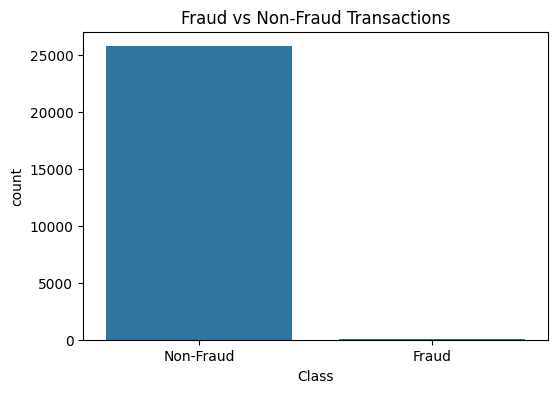

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['Class'])
plt.title("Fraud vs Non-Fraud Transactions")
plt.xticks([0,1], ["Non-Fraud", "Fraud"])
plt.show()

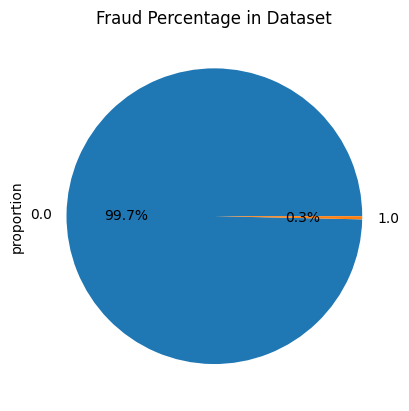

In [ ]:
fraud_perc = df["Class"].value_counts(normalize=True)
fraud_perc.plot.pie(autopct='%1.1f%%')
plt.title("Fraud Percentage in Dataset")
plt.show()

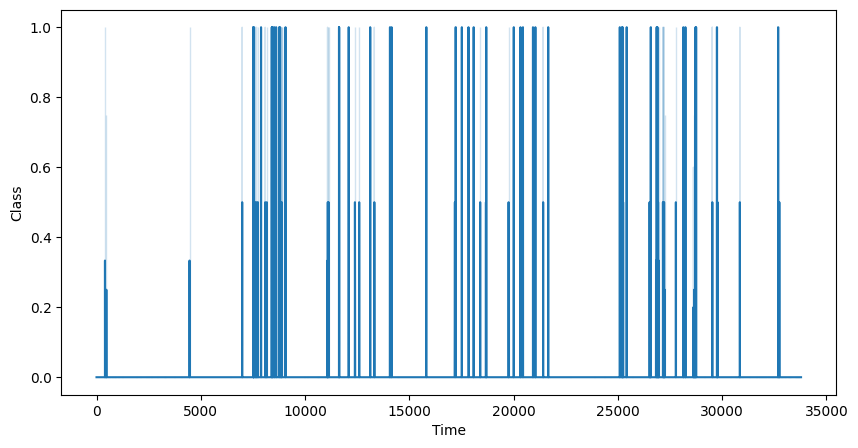

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(x='Time', y='Class', data=df)
plt.show()

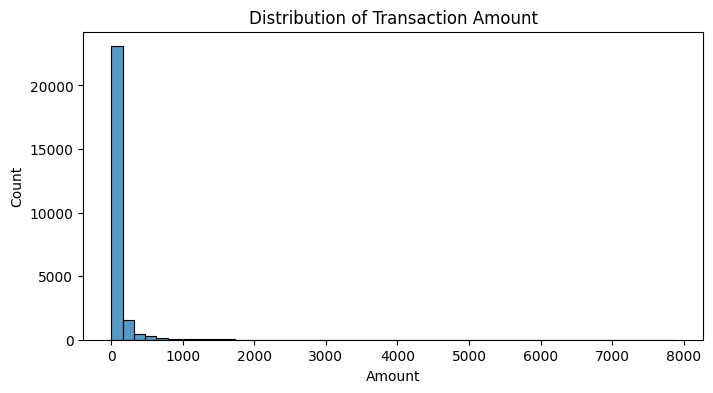

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['Amount'], bins=50)
plt.title("Distribution of Transaction Amount")
plt.show()

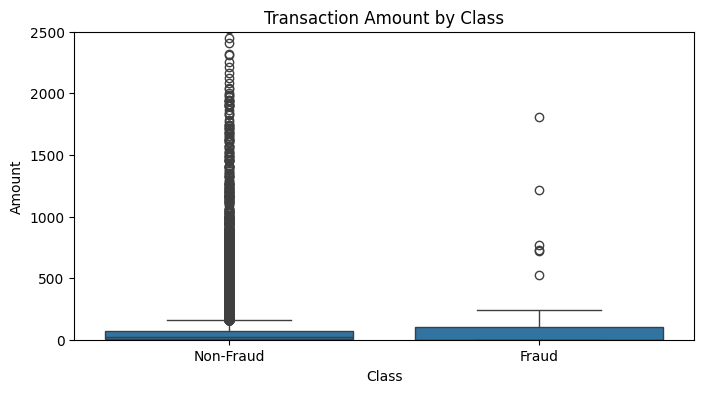

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Transaction Amount by Class")
plt.xticks([0,1], ["Non-Fraud", "Fraud"])
plt.ylim(0, 2500)
plt.show()

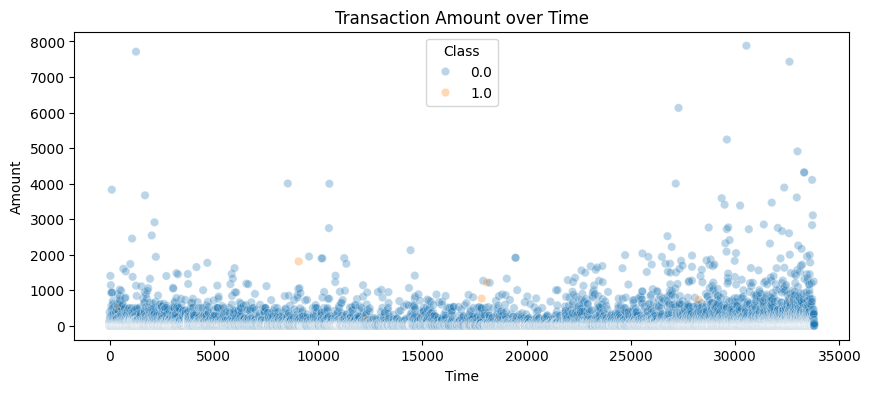

In [ ]:
plt.figure(figsize=(10,4))
sns.scatterplot(x='Time', y='Amount', hue='Class', data=df, alpha=0.3)
plt.title("Transaction Amount over Time")
plt.show()

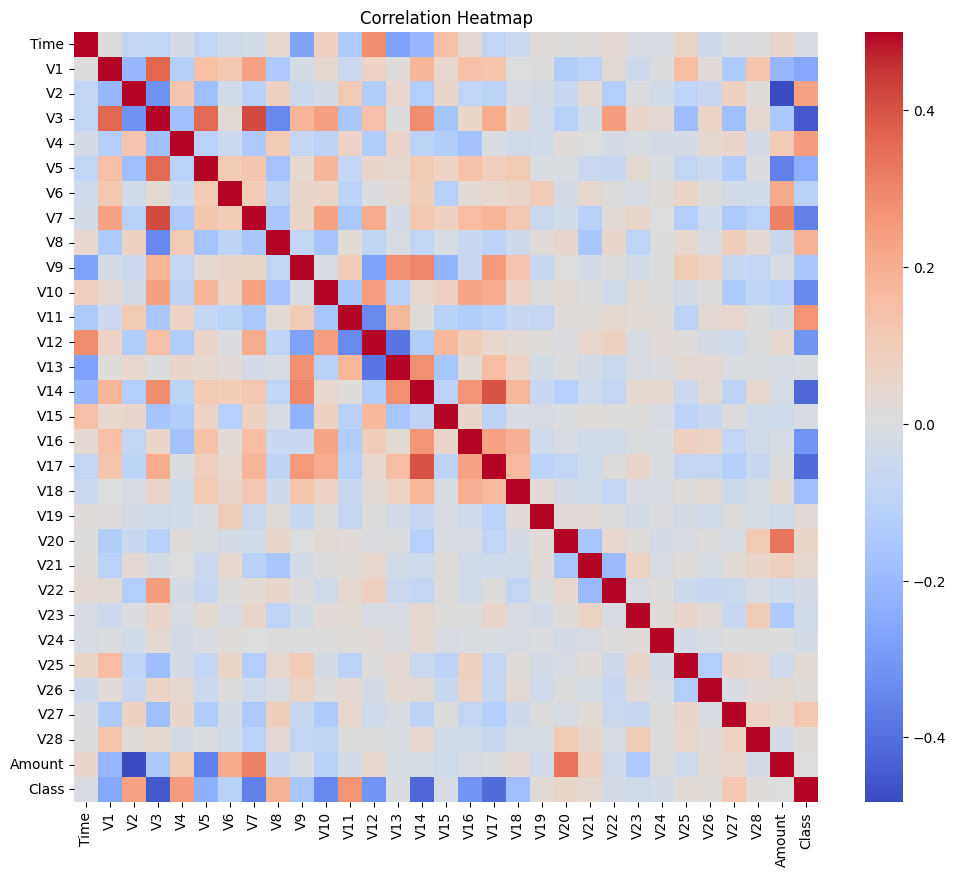

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', vmax=0.5)
plt.title("Correlation Heatmap")
plt.show()

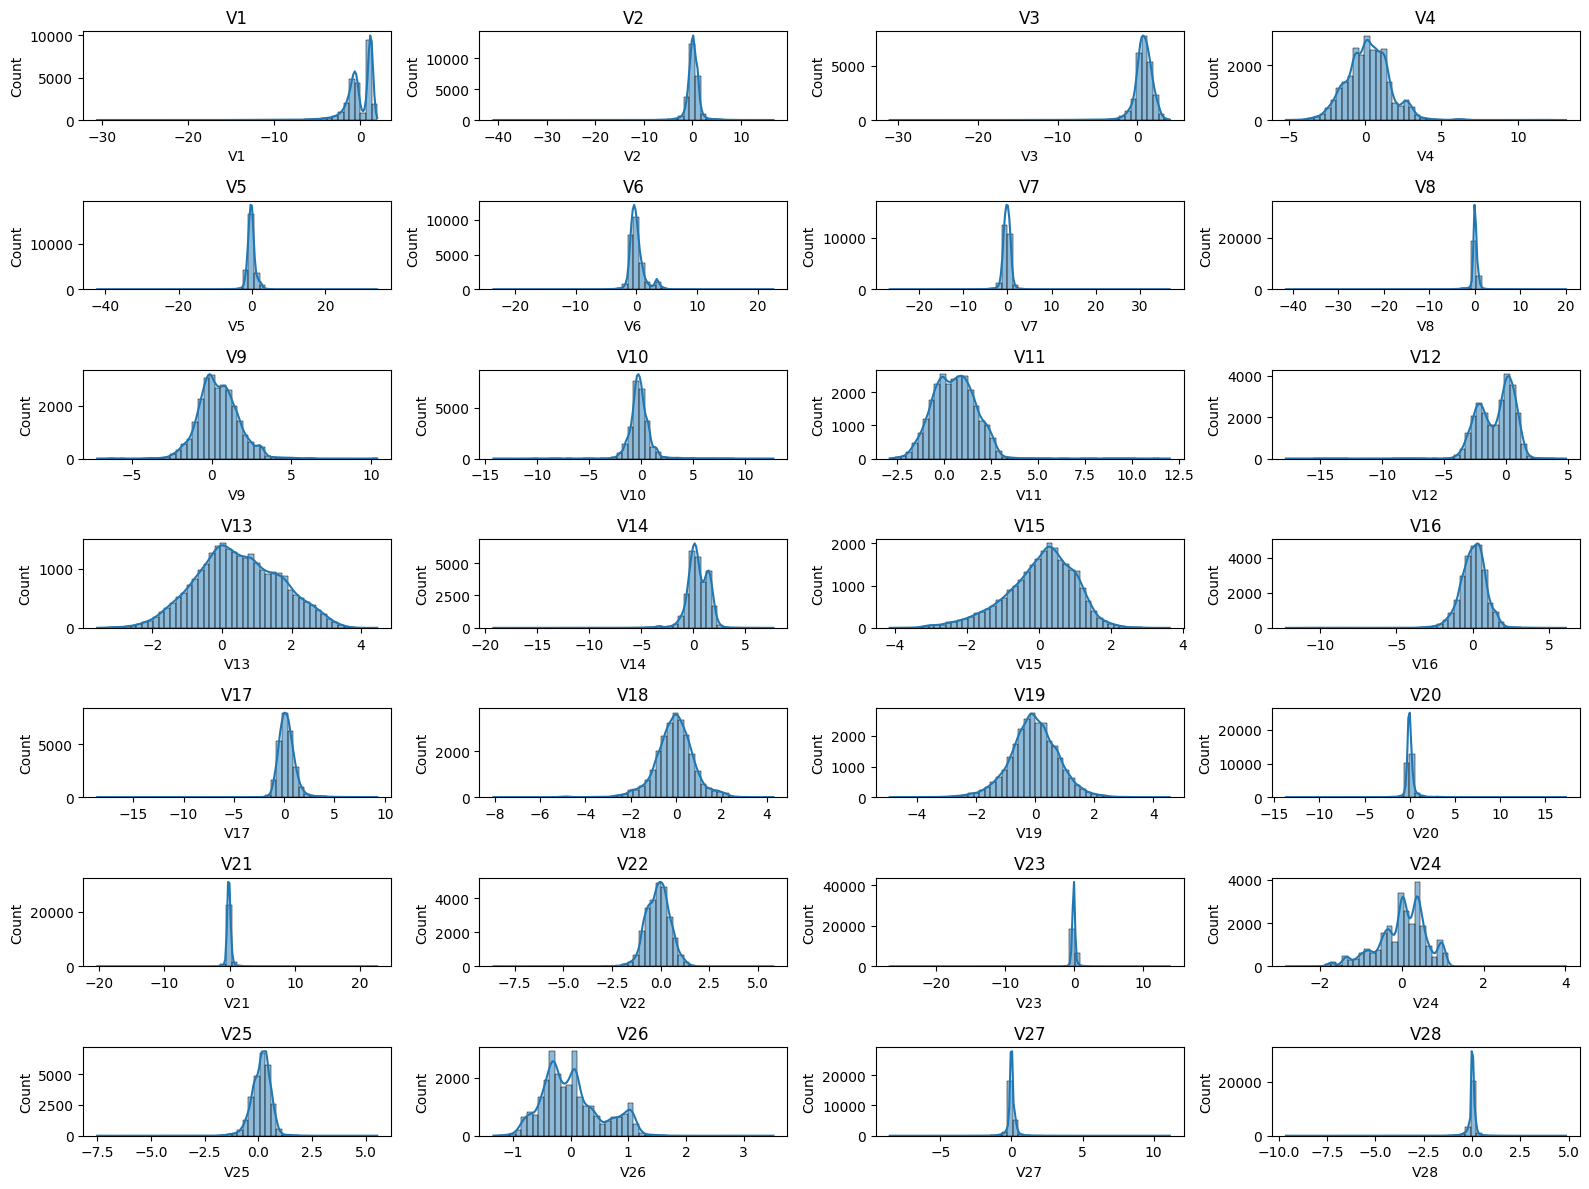

In [ ]:
v_features = df.columns[1:-2]  # V1 to V28
plt.figure(figsize=(16,12))
for i, col in enumerate(v_features, 1):
    plt.subplot(7,4,i)
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

In this credit card fraud dataset, we identified a heavy class imbalance with very few fraud cases. Transaction amounts vary widely across fraud and non-fraud cases. Visualization of features such as Amount, Time, and principal components (V1–V28) provides insights into potential patterns that can be useful for feature engineering during modeling. Correlation heatmap helps understand relationships between variables.

**Key Insights From the Analysis**

1 — Fraud Is Extremely Rare

Fraud transactions are less than 0.2% of total data. This proves why fraud detection is difficult in real life.

2 — Fraud Transactions Often Have Different Amount Patterns

Boxplots showed fraud amounts behave differently from normal transactions.

3 — Certain PCA Features Show Distinct Distributions

Some components (like V14, V12, V10 in many analyses) show visibly different curves for fraud cases.

4 — No Missing Values

The dataset is clean and ready for machine learning without heavy preprocessing.

5 — Weak Direct Correlation With Amount and Time

Fraud cannot be detected using Amount or Time alone. Hidden patterns in V1–V28 are more important.